In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import math

        
def my_plot(file_pattern,initial_num,global_best,label,regret=True,color='red',fmt='-o',length=51):
    
    file_list = glob.glob(file_pattern)

# Initialize a list to hold the data
    data = []

    # Read each file and append the data to the list
    
    for file_name in file_list:
        df = pd.read_csv(file_name, header=None)
        temp_np= df.values.flatten()

        if len(temp_np) < length:
            temp_np = np.pad(temp_np, (0, length - len(temp_np)), mode='constant',constant_values=-100)


        data.append(temp_np)
        
    print(len(data))

    # Convert the list of data into a numpy array
    data_array = np.array(data)
    data_array = np.maximum.accumulate(data_array, axis=1)#[:,initial_num-1:]
    
    if regret:
        data_array = global_best - data_array
        # data_array[data_array<10**(-6.)]=10**(-6.)
    else:
        data_array = data_array
    
    
    num = data_array.shape[0]

    # Step 2: Calculate mean and error bounds
    means = np.mean(data_array, axis=0)
    std_devs = np.std(data_array, axis=0)/math.sqrt(num)  # Standard deviation as error bounds
    

    means = means [initial_num-1:-1] 
    std_devs = std_devs [initial_num-1:-1] 
    # means = means[::step]
    # std_devs = std_devs[::step]

    print('mean is ',means[-1])

    # Step 3: Plot the data
    x = np.arange(len(means)) # X-axis values
    plt.errorbar(x, means, yerr=std_devs, fmt=fmt, capsize=5, label=label,color=color)      
        


def precent_plot(file_pattern,initial_num,global_best,label,regret=True,color='red',fmt='-o'):
    
    file_list = glob.glob(file_pattern)

# Initialize a list to hold the data
    data = []

    # Read each file and append the data to the list
    
    for file_name in file_list:
        df = pd.read_csv(file_name, header=None)
        temp_np= df.values.flatten()
        data.append(temp_np)
        
    print(len(data))

    # Convert the list of data into a numpy array
    data_array = np.array(data)
    data_array = np.maximum.accumulate(data_array, axis=1)#[:,initial_num-1:]
    
    # if regret:
    #     data_array = global_best - data_array
    #     # data_array[data_array<10**(-6.)]=10**(-6.)
    # else:
    #     data_array = data_array
    data_array *= 100
    data_array = data_array/global_best
    num = data_array.shape[0]

    # Step 2: Calculate mean and error bounds
    means = np.mean(data_array, axis=0)
    std_devs = np.std(data_array, axis=0)/math.sqrt(num)  # Standard deviation as error bounds
    

    means = means [initial_num-1:-1] 
    std_devs = std_devs [initial_num-1:-1] 
    # means = means[::step]
    # std_devs = std_devs[::step]

    print('mean is ',means[-1])

    # Step 3: Plot the data
    x = np.arange(len(means)) # X-axis values
    plt.errorbar(x, means, yerr=std_devs, fmt=fmt, capsize=5, label=label,color=color)      


def check_max(file_pattern):
    
    file_list = glob.glob(file_pattern)

# Initialize a list to hold the data
    data = []

    # Read each file and append the data to the list
    for file_name in file_list:
        df = pd.read_csv(file_name, header=None)
        temp_np= df.values.flatten()
        data.append(temp_np)
        
    print(len(data))

    # Convert the list of data into a numpy array
    data_array = np.array(data)
    data_array = np.maximum.accumulate(data_array, axis=1)#[:,initial_num-1:]


    return np.max(data_array)

10
1
mean is  0.0027725487113912095
1
mean is  0.0009891963582049357
1
mean is  0.03726158267932078


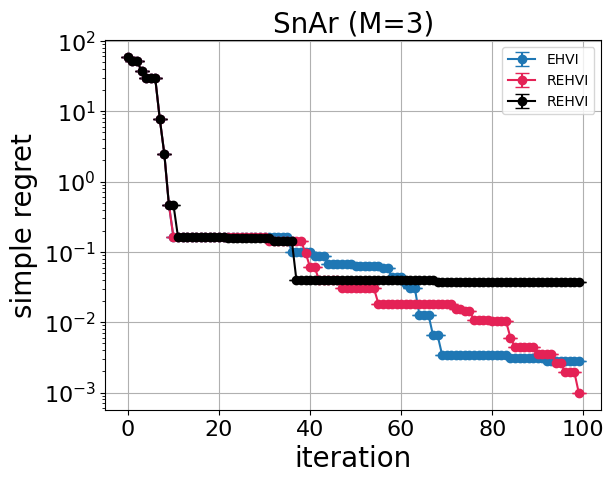

In [16]:
global_best = check_max('exp/M3/'+f'SnAr_EHVI_M_M=3_*')+1e-6

num = '0'


file_pattern = 'exp/M3/'+f'SnAr_EHVI_M=0_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='EHVI',color='#1f77b4')



file_pattern = 'exp/M3/'+f'SnAr_EHVI_M_M=3_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='REHVI',color='#E42256')

file_pattern = 'exp2/M3/'+f'SnAr_EHVI_M_M=3_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='REHVI',color='black')

plt.grid(True)
plt.legend()

plt.xlabel('iteration',fontsize=20)
plt.ylabel('simple regret',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('SnAr (M=3)',fontsize=20)

plt.yscale("log") 

10
10
mean is  0.03924918542393385
10
mean is  0.00032868709189415313


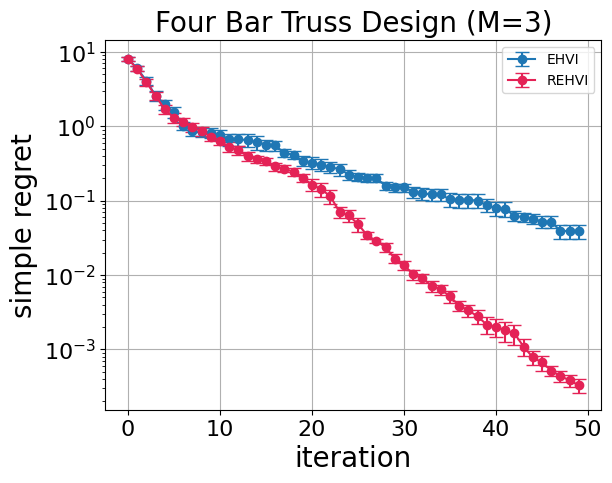

In [7]:
global_best = check_max('exp/M3/'+f'Four_bar_truss_design_EHVI_M_M=3_*')+1e-6

num = '*'


file_pattern = 'exp/M3/'+f'Four_bar_truss_design_EHVI_M=0_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='EHVI',color='#1f77b4')



file_pattern = 'exp/M3/'+f'Four_bar_truss_design_EHVI_M_M=3_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='REHVI',color='#E42256')

plt.grid(True)
plt.legend()

plt.xlabel('iteration',fontsize=20)
plt.ylabel('simple regret',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('Four Bar Truss Design (M=3)',fontsize=20)

plt.yscale("log") 

10
10
mean is  103.02399619578023
10
mean is  64.63899719396859


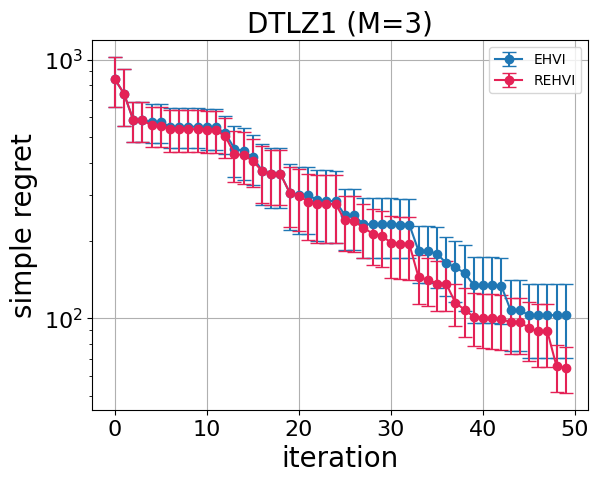

In [10]:
global_best = check_max('exp/M3/'+f'DTLZ1_EHVI_M_M=3_*')+1e-6

num = '*'

file_pattern = 'exp/M3/'+f'DTLZ1_EHVI_M=0_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='EHVI',color='#1f77b4')

file_pattern = 'exp/M3/'+f'DTLZ1_EHVI_M_M=3_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='REHVI',color='#E42256')


plt.grid(True)
plt.legend()

plt.xlabel('iteration',fontsize=20)
plt.ylabel('simple regret',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('DTLZ1 (M=3)',fontsize=20)

plt.yscale("log") 

10
10
mean is  0.0016357316123548182
10
mean is  1.560621424490094e-06


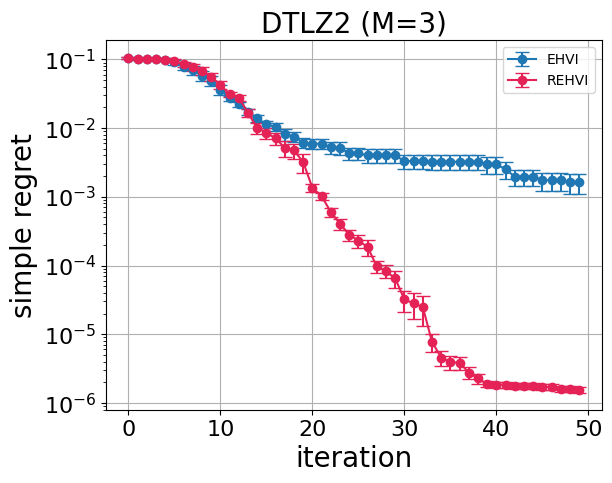

In [11]:
global_best = check_max('exp/M3/'+f'DTLZ2_EHVI_M_M=3_*')+1e-6

num = '*'

file_pattern = 'exp/M3/'+f'DTLZ2_EHVI_M=0_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='EHVI',color='#1f77b4')

file_pattern = 'exp/M3/'+f'DTLZ2_EHVI_M_M=3_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='REHVI',color='#E42256')


plt.grid(True)
plt.legend()

plt.xlabel('iteration',fontsize=20)
plt.ylabel('simple regret',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('DTLZ2 (M=3)',fontsize=20)

plt.yscale("log") 

10
10
mean is  0.07047629719758675
10
mean is  0.03462733725680493


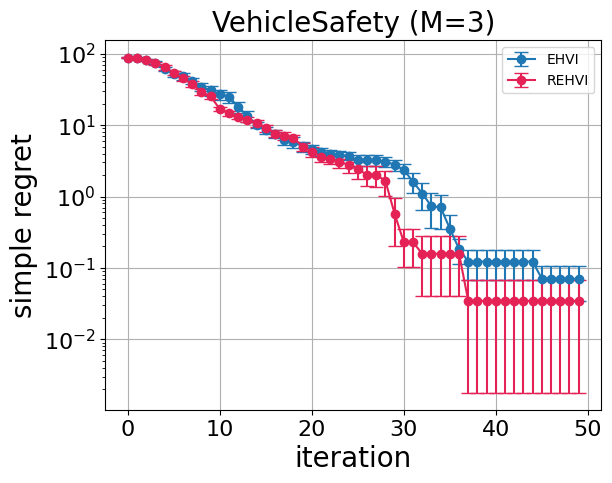

In [12]:
global_best = check_max('exp/M3/'+f'VehicleSafety_EHVI_M_M=3_*')+1e-6

num = '*'

file_pattern = 'exp/M3/'+f'VehicleSafety_EHVI_M=0_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='EHVI',color='#1f77b4')

file_pattern = 'exp/M3/'+f'VehicleSafety_EHVI_M_M=3_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='REHVI',color='#E42256')


plt.grid(True)
plt.legend()

plt.xlabel('iteration',fontsize=20)
plt.ylabel('simple regret',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('VehicleSafety (M=3)',fontsize=20)

plt.yscale("log") 

10
10
mean is  0.01189345397905015
10
mean is  0.0003012646804881669


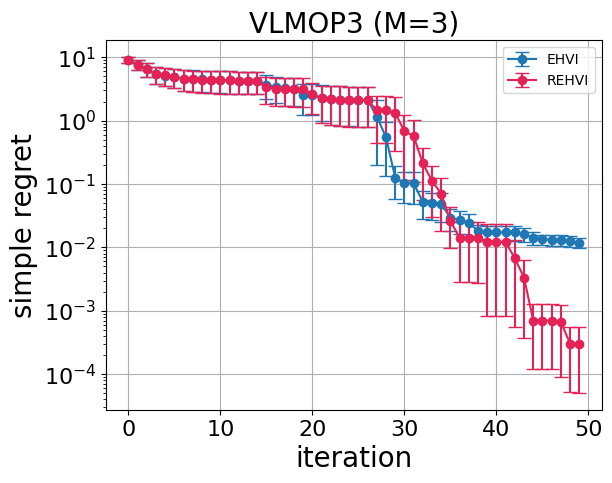

In [13]:
global_best = check_max('exp/M3/'+f'VLMOP3_EHVI_M_M=3_*')+1e-6

num = '*'

file_pattern = 'exp/M3/'+f'VLMOP3_EHVI_M=0_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='EHVI',color='#1f77b4')

file_pattern = 'exp/M3/'+f'VLMOP3_EHVI_M_M=3_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='REHVI',color='#E42256')


plt.grid(True)
plt.legend()

plt.xlabel('iteration',fontsize=20)
plt.ylabel('simple regret',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('VLMOP3 (M=3)',fontsize=20)

plt.yscale("log") 

10
10
mean is  0.0008665044937244182
10
mean is  3.3966174584620923e-06


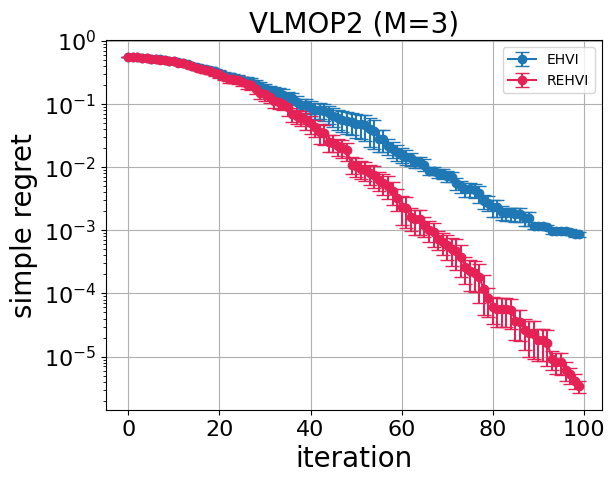

In [14]:
global_best = check_max('exp/M3/'+f'VLMOP2_EHVI_M_M=3_*')+1e-6

num = '*'

file_pattern = 'exp/M3/'+f'VLMOP2_EHVI_M=0_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='EHVI',color='#1f77b4')

file_pattern = 'exp/M3/'+f'VLMOP2_EHVI_M_M=3_{num}'  # Pattern to match your text files
my_plot(file_pattern=file_pattern,initial_num=1,global_best=global_best,label='REHVI',color='#E42256')


plt.grid(True)
plt.legend()

plt.xlabel('iteration',fontsize=20)
plt.ylabel('simple regret',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('VLMOP2 (M=3)',fontsize=20)

plt.yscale("log") 